-   Task 1  Data prep (returns, train/test split)
-   Task 2  Flexible probabilities, weighted mean/covariance, ENS
-   Task 3  PCA — eigendecomposition, scree plot, interpreting PC1/PC2
-   Task 4  out-of-sample reconstruction on 2025 data (does the factor structure hold up?)
-   Task 5  economic interpretation as portfolios (you actually already did an informal version of this when we discussed PC1/PC2's meaning

Task 1 first — data prep

In [1]:
import pandas as pd
import yfinance as yf


In [6]:
import matplotlib.pyplot as plt

In [ ]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "AMD", "INTC", "CRM", "ORCL", "ADBE", "CSCO", "IBM"]
start="2024-01-01"
end="2025-09-30"
data = {}
for ticker in tickers :
    data[ticker] = yf.download(ticker, start=start, end=end, auto_adjust=True)["Close"].squeeze()
    # print(ticker, type(data[ticker]), data[ticker].shape if hasattr(data[ticker], "shape") else "scalar")
dataframe = pd.DataFrame(data)

In [5]:
daily_returns = dataframe.pct_change().dropna()  
train_returns = daily_returns.loc["2024-01-01":"2024-12-31"]
test_returns = daily_returns.loc["2025-01-01":"2025-09-30"]

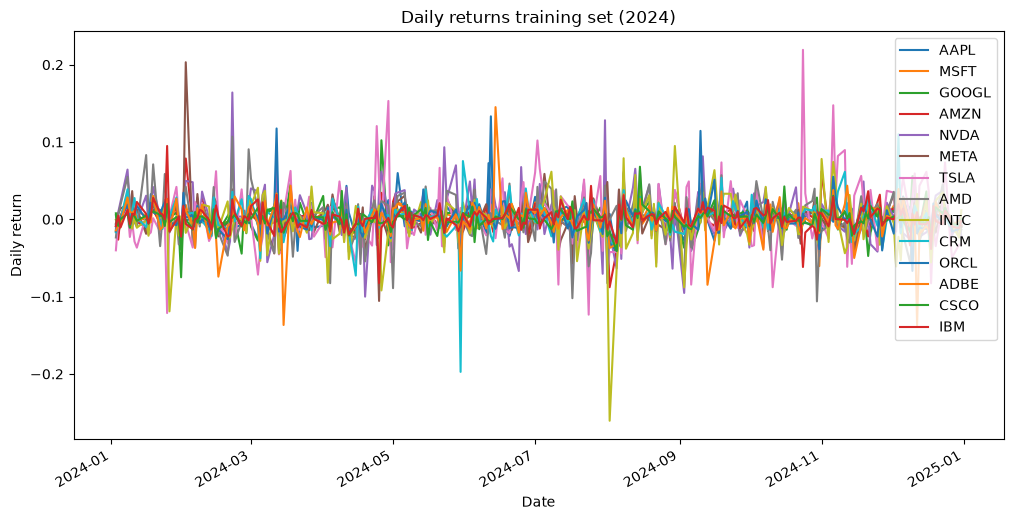

In [7]:
train_returns.plot(figsize=(12,6), title="Daily returns training set (2024)")
plt.xlabel("Date")
plt.ylabel("Daily return")
plt.show()

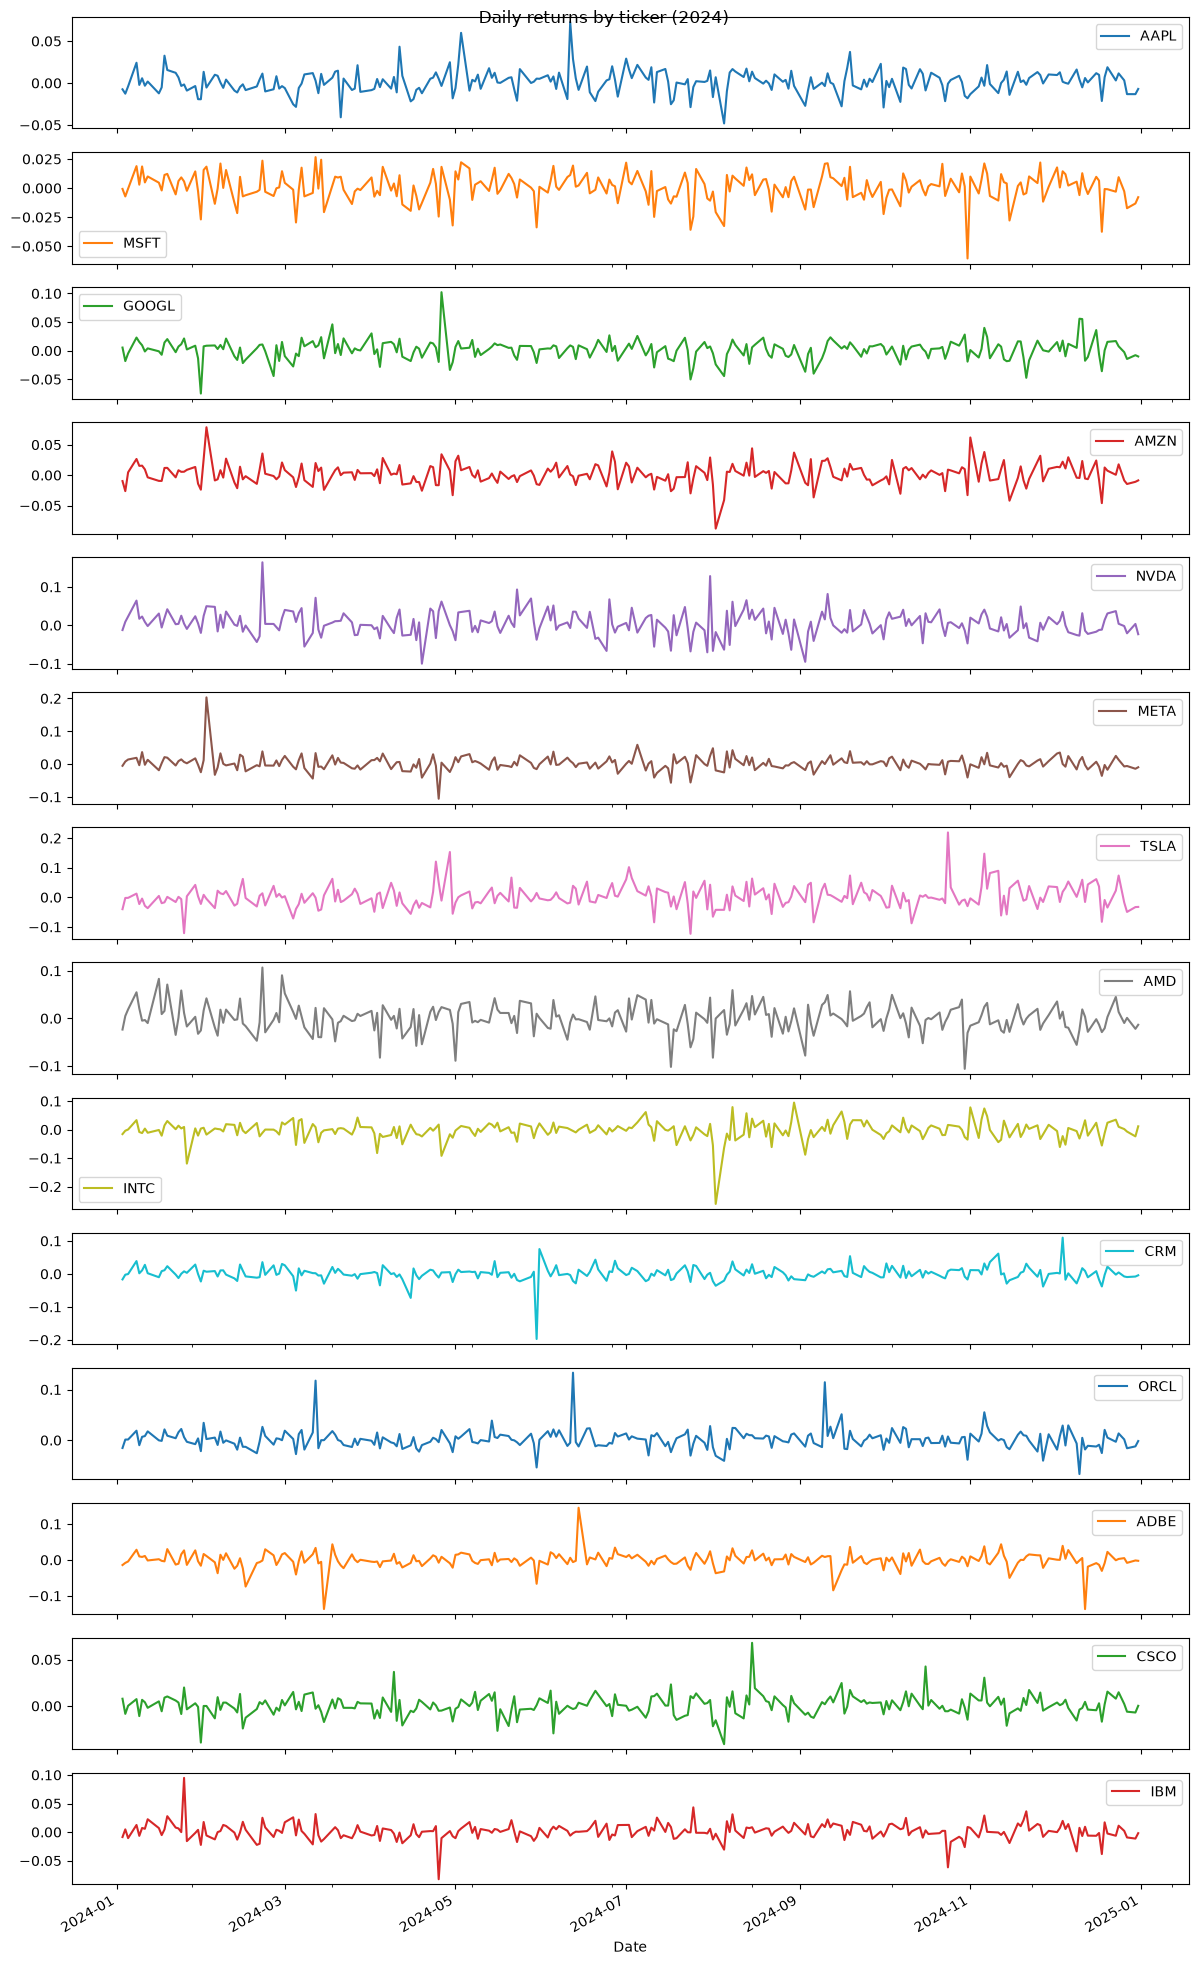

In [8]:
axes = train_returns.plot(subplots=True, figsize=(12,20), title="Daily returns by ticker (2024)")
plt.tight_layout()
plt.show()

The goal of this workshop is to detect our principal components. For that we will use the covariance matrix, but by default this matrix gives equal weight to every day. Here we don't do that, but gives more weight to recent days than older days. 

Task 2: Flexible probabilities + weighted mean/covariance

In [10]:
import numpy as np

In [11]:
def exp_decay_probs(t_bar, half_life):
    # distance = [(t_bar - 1) - t for t in range(t_bar)]
    distance = np.arange(t_bar - 1, -1, -1)
    rate = np.log(2)/half_life
    raw_weight = np.exp(-rate * distance)
    normalize = sum(raw_weight)
    p = raw_weight/normalize
    return p


In [12]:
p = exp_decay_probs(len(train_returns), 60)
print(p.sum())    # should be ~1.0
print(p[-5:])      # last 5 values — should be the largest
print(p[:5]) 

1.0000000000000007
[0.01160611 0.01174097 0.01187739 0.0120154  0.01215501]
[0.00067681 0.00068467 0.00069262 0.00070067 0.00070881]


In [13]:
def effective_number_scenario(p) :
    ens = np.exp(- sum(p * np.log(p)))
    return ens

In [14]:
p_decay = exp_decay_probs(len(train_returns), 60)
print(effective_number_scenario(p_decay))

p_uniform = np.ones(len(train_returns)) / len(train_returns)
print(effective_number_scenario(p_uniform))

187.79480464263324
251.00000000000213


In [26]:
def weighted_mean(return_df, p):
    w_mu = return_df.mul(p, axis=0).sum()
    return w_mu

def weighted_cov(return_df, p):
    demeaned_X = (return_df - weighted_mean(return_df, p)).values
    #Cov = X'PX
    matrix_P = np.diag(p)
    w_cov = demeaned_X.T @ matrix_P.T @ demeaned_X   
    return w_cov


In [28]:
w_mean = weighted_mean(train_returns, p_decay)
w_cov = weighted_cov(train_returns, p_decay)

print(w_cov.shape)
print(np.diagonal(w_cov)[:5])
print(train_returns.var()[:5] * (len(train_returns)-1)/len(train_returns))

(14, 14)
[0.0001665  0.00016315 0.00032359 0.00033506 0.00090803]
AAPL     0.000199
MSFT     0.000157
GOOGL    0.000312
AMZN     0.000312
NVDA     0.001090
dtype: float64


Task 3: PCA — eigendecomposition

Two steps:

Rescale w_cov to a correlation matrix first (puts every stock on equal footing regardless of its raw volatility, so PCA isn't dominated by whichever stock happens to be loudest).
Eigendecompose the correlation matrix, sort eigenvalues descending, and plot them to look for an "elbow."

In [32]:
def cov_to_corr(cov):
    # if D is a matrix of standard deviations, then corr = D^-1 * Cov * D^-1
    std = np.sqrt(np.diagonal(cov))   # 1-D array of standard deviations
    D_inv = np.diag(1/std)   # diagonal matrix of 1/sigma_i
    corr = D_inv @ cov @ D_inv
    return corr

In [33]:
corr = cov_to_corr(w_cov)
print(np.diagonal(corr))   # should be all ~1.0 (a stock's correlation with itself)
print(corr[0,1])            # AAPL-MSFT correlation, should be between -1 and 1

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
0.5226334291928555


In [36]:
eigenvalues, eigenvectors = np.linalg.eigh(corr)
eigenvalues = eigenvalues[:: -1]        # reverse the 1-D array
eigenvectors = eigenvectors[:, ::-1]    # reverse the *columns*, keep rows as-is

In [37]:
print(eigenvalues)
print(eigenvalues.sum())        # should be ~14
print((eigenvalues > 0).all())  # should be True

[5.34852559 1.33928773 1.07346602 0.93504694 0.89824528 0.74463445
 0.71489618 0.65840726 0.52897305 0.4765623  0.41928565 0.36866716
 0.26022396 0.23377844]
13.999999999999996
True


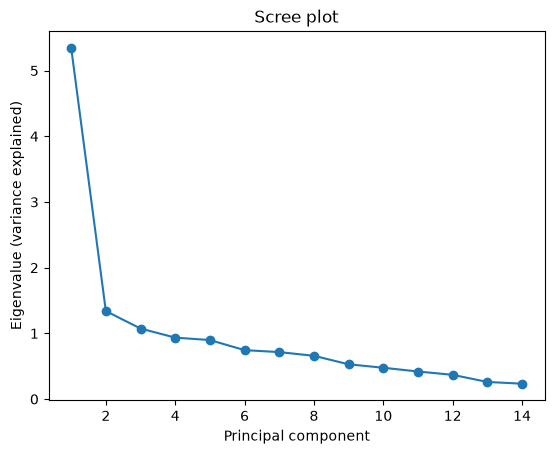

In [38]:
plt.plot(range(1, 15), eigenvalues, marker='o')
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue (variance explained)")
plt.title("Scree plot")
plt.show()

PC1's eigenvalue is 5.35 out of 14 total, meaning the first principal component alone explains 5.35/14≈38% of all the co-movement variance across your 14 stocks. That's a real, meaningful common factor (likely something like "broad tech market moves"). PC2 only adds another 
1.34/14≈10%, and from there the eigenvalues decay fairly gradually (1.07, 0.94, 0.90, ...) rather than falling off a cliff — no dramatic single elbow, more of a gentle slope after PC1.

There's one dominant shared factor, but not a clean "2-factor world". The remaining variance is spread fairly evenly across many smaller directions rather than concentrating into a clear second or third factor. This is realistic for a basket of tech stocks with different sub-sectors mixed in (chips, software, e-commerce, social media); they share broad market exposure but don't collapse into just 2-3 dominant clusters.

In [39]:
pc1_weights = pd.Series(eigenvectors[:, 0], index=train_returns.columns)
pc2_weights = pd.Series(eigenvectors[:, 1], index=train_returns.columns)

print("PC1 weights:")
print(pc1_weights.sort_values(ascending=False))

print("\nPC2 weights:")
print(pc2_weights.sort_values(ascending=False))

PC1 weights:
MSFT     0.355284
AMZN     0.349773
META     0.291107
NVDA     0.278745
ORCL     0.273101
GOOGL    0.270385
AMD      0.265080
CRM      0.255744
INTC     0.248736
AAPL     0.232678
CSCO     0.231229
TSLA     0.224561
ADBE     0.223561
IBM      0.189056
dtype: float64

PC2 weights:
IBM      0.519822
CSCO     0.422599
CRM      0.296140
ORCL     0.234042
INTC     0.117320
ADBE     0.087739
AMD      0.028777
NVDA    -0.002061
AMZN    -0.106531
MSFT    -0.161099
TSLA    -0.209614
META    -0.267279
AAPL    -0.291621
GOOGL   -0.385624
dtype: float64


PC1: confirms the "broad market factor" story

Every single one of the 14 weights is positive, no sign flips at all.
Magnitudes: MSFT (0.355), AMZN (0.350), META (0.291) sit at the top. These are the stocks most representative of/sensitive to the common factor. IBM (0.189), ADBE (0.224), TSLA (0.225) sit at the bottom, still positive, but less tied to the group's common movement (IBM in particular stands out as the least "market-following" of the 14, which tracks — it's a legacy/enterprise name, less correlated with high-growth tech sentiment).

PC2: a genuine "this vs. that" split, and an interesting one

Positive side: IBM (0.52), CSCO (0.42), CRM (0.30), ORCL (0.23) : these are enterprise/legacy software & infrastructure names: older, more stable, less "hype"-driven business models.

Negative side: GOOGL (-0.39), AAPL (-0.29), META (-0.27), TSLA (-0.21) : consumer-facing big tech / high-growth names.

Near zero: NVDA (-0.002), AMD (0.03) : interesting: the two big semiconductor/AI names sit almost exactly at the boundary, barely loading on this axis at all.

PC2 is capturing a spectrum from "old-guard enterprise tech" (IBM, CSCO, Oracle) on one end to "consumer-facing growth tech" (Google, Apple, Meta, Tesla) on the other with chipmakers (NVDA, AMD) sitting neutral, since they arguably sell into both camps and aren't cleanly on either side of that particular divide.

Task 4: Out-of-sample reconstruction — does the model generalize?
The goal, in plain terms

We fit PC1/PC2 using only 2024 data. If the "shape" of how these 14 stocks co-move (the correlation structure PCA discovered) is a stable, persistent characteristic of these companies, then applying 2024's compression recipe to fresh 2025 data should still reconstruct it reasonably well. If the correlation structure was actually just a 2024-specific fluke (regime-dependent, not a real lasting pattern), the reconstruction on 2025 data will look noticeably worse — a mismatch that reveals your "factor structure" was overfit to last year and doesn't generalize.

In [56]:
e_k = eigenvectors[:, :2] #top 2 eigenvectors (14, 2)

demeaned_test_returns = test_returns.values - w_mean.values  #We used w_mean because we don't want to leak information
#Project unto ek
projection = demeaned_test_returns @ e_k   #Or compression
decompression = projection @ e_k.T 

predicted_values = decompression + w_mean.values
predicted = pd.DataFrame(predicted_values, index=test_returns.index, columns=test_returns.columns)
# predicted = demeaned_test_returns + (test_returns - demeaned_test_returns) @ e_k @ e_k.T  # compression and decompression on this one line hat(X) = bar(X) + (X - bar(X)) * ek * ek' 

In [57]:
correlation_per_stock = pd.Series({
    ticker: np.corrcoef(test_returns[ticker], predicted[ticker])[0, 1] for ticker in test_returns.columns
})
print(correlation_per_stock.sort_values(ascending=False))

AMZN     0.827364
NVDA     0.819105
META     0.810450
AMD      0.802770
TSLA     0.795166
MSFT     0.780553
GOOGL    0.767980
AAPL     0.747946
CSCO     0.734955
ORCL     0.652378
IBM      0.648142
CRM      0.646010
ADBE     0.579388
INTC     0.551059
dtype: float64


Every single stock has a positive, fairly high correlation between actual and reconstructed 2025 returns, ranging from 0.55 (INTC) to 0.83 (AMZN)

High correlation (AMZN, NVDA, META, AMD, TSLA): these had large-magnitude weights on PC1 and/or a clear position on PC2 i.e., they're stocks whose behavior is strongly explained by the two dominant factors we found.
Lower correlation (INTC, ADBE, CRM, IBM): these had comparatively smaller PC1 weights and are closer to the "neutral zone" on various axes, meaning more of their actual movement comes from idiosyncratic, company-specific noise that a 2-factor model can't capture by design

Task 5: Factor portfolios — formalizing the interpretation

Step 1 — Turn eigenvectors into proper portfolio weights

Raw eigenvectors are normalized to unit length, not to sum to 1 like typical portfolio weights (dollar-neutral or fully-invested conventions).

In [58]:
# combine full history for a continuous plot
all_returns = pd.concat([train_returns, test_returns])

pc1_portfolio_returns = (all_returns.values - w_mean.values) @ eigenvectors[:, 0]
pc2_portfolio_returns = (all_returns.values - w_mean.values) @ eigenvectors[:, 1]

pc1_series = pd.Series(pc1_portfolio_returns, index=all_returns.index)
pc2_series = pd.Series(pc2_portfolio_returns, index=all_returns.index)

Step 2 — Plot both factor portfolios' cumulative performance

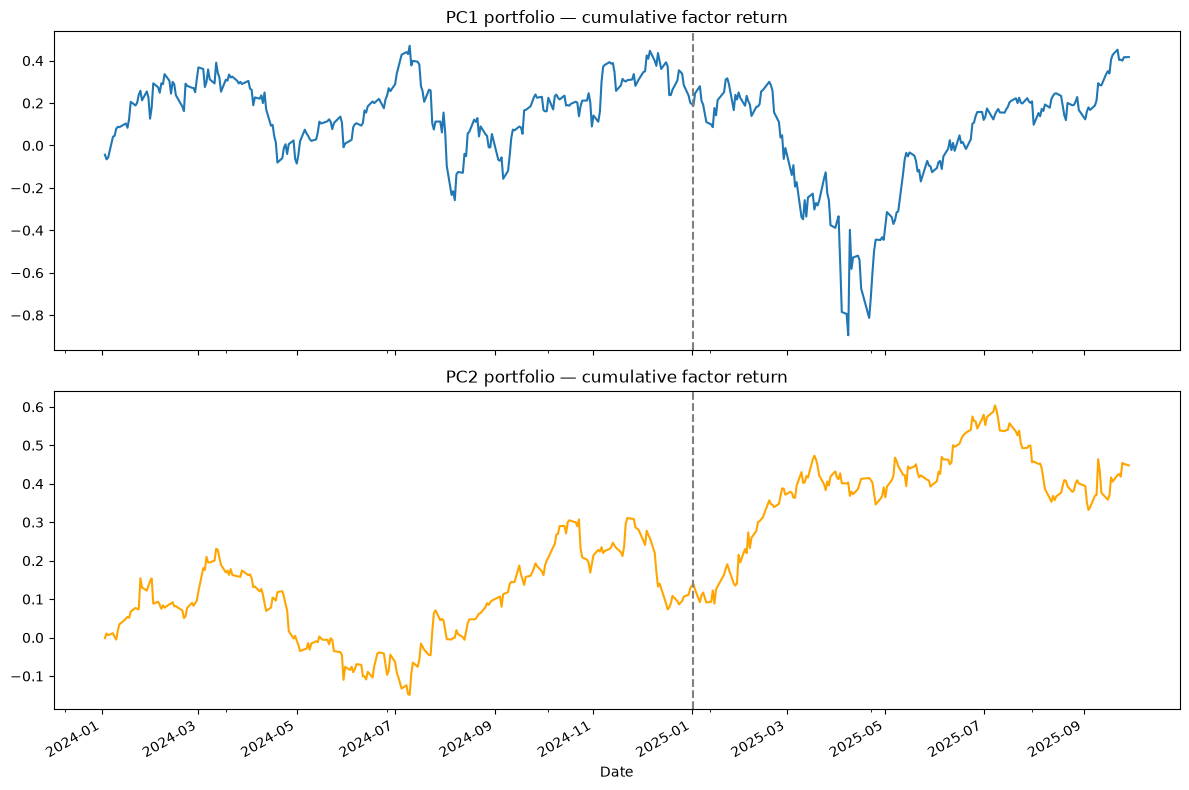

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
pc1_series.cumsum().plot(ax=axes[0], title="PC1 portfolio — cumulative factor return")
pc2_series.cumsum().plot(ax=axes[1], title="PC2 portfolio — cumulative factor return", color='orange')
axes[0].axvline(test_returns.index[0], color='gray', linestyle='--', label='train/test split')
axes[1].axvline(test_returns.index[0], color='gray', linestyle='--')
plt.tight_layout()
plt.show()

PC1 : "broad tech market" factor

Choppy but roughly range-bound through most of 2024, oscillating between about 0 and 0.4. Then a sharp, deep drawdown around March-May 2025, a dive down to nearly -0.9 before recovering back to positive territory by late 2025. That's a big, synchronized move.

PC2: "enterprise/legacy vs. consumer growth" factor

A much steadier, more persistent upward drift across almost the entire period — some chop, but a clear overall climb from ~0 to ~0.45-0.6, especially strengthening from late 2024 through mid-2025. Recall the composition: positive side (IBM, CSCO, CRM, ORCL) vs negative side (GOOGL, AAPL, META, TSLA). A steadily rising PC2 tells you: over this period, "enterprise/legacy" names systematically outperformed "consumer growth" names, in relative terms, a genuine rotation/trend, not just noise oscillating around zero.
